# Fraud Detection Model Building

This notebook performs:
- Data preparation
- Train/test split
- Class imbalance handling
- Baseline model training
- Ensemble model training
- Model evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
data_path = Path(
    "../data/processed/fraud_model_ready.csv"
)

df = pd.read_csv(data_path)

In [3]:
df.head()

,purchase_value,age,ip_address_int,hour_of_day,purchase_month,is_weekend,time_since_signup_hours,user_transaction_count,device_transaction_count,source_Direct,...,country_Yemen,country_Zambia,country_Zimbabwe,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,class
0,0.494721,0.331793,-1.723753,-0.220124,-1.130797,1.568716,-1.013679,0.0,-0.261514,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,-0.214781,-0.364448,-1.723720,0.792542,-1.130797,-0.637464,-1.230613,0.0,-0.261514,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.214781,-0.132367,-1.723710,-0.509456,-0.379095,-0.637464,-1.337931,0.0,-0.261514,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,-0.214781,0.795954,-1.723700,1.371208,-0.379095,-0.637464,0.800513,0.0,-0.261514,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.985915,0.563874,-1.723689,-0.654123,-0.754946,1.568716,-1.127359,0.0,-0.261514,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [4]:
df.shape

(151112, 204)

In [5]:
X = df.drop(
    "class",
    axis=1
)

y = df["class"]

In [6]:
X.shape, y.shape

((151112, 203), (151112,))

In [7]:
y.value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [8]:
y.value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

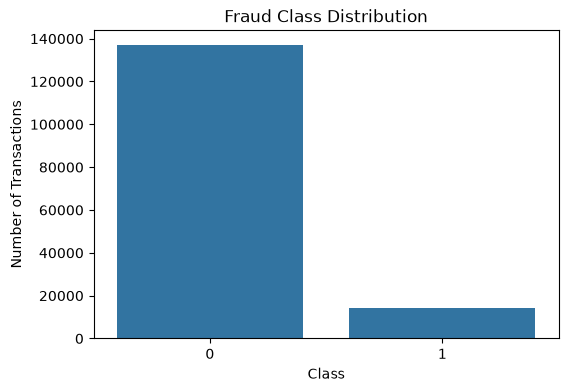

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y
)

plt.title(
    "Fraud Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Transactions"
)

plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
y_train.value_counts(normalize=True)

class
0    0.906352
1    0.093648
Name: proportion, dtype: float64

In [12]:
y_test.value_counts(normalize=True)

class
0    0.906363
1    0.093637
Name: proportion, dtype: float64

In [13]:
smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [14]:
y_train_resampled.value_counts()

class
0    109568
1    109568
Name: count, dtype: int64

## Handling Class Imbalance

The dataset contains significantly fewer fraud transactions than legitimate transactions.

SMOTE was selected because:
- It creates synthetic minority samples.
- It prevents the model from ignoring fraud cases.
- It avoids removing useful legitimate transactions.

SMOTE was applied only to the training set to prevent data leakage.

In [15]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [16]:
log_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [17]:
log_predictions = log_model.predict(
    X_test
)

In [18]:
log_probabilities = log_model.predict_proba(
    X_test
)[:,1]

In [19]:
log_f1 = f1_score(
    y_test,
    log_predictions
)

log_f1

0.6121768140116765

In [20]:
log_auc_pr = average_precision_score(
    y_test,
    log_probabilities
)

log_auc_pr

0.659632425300959

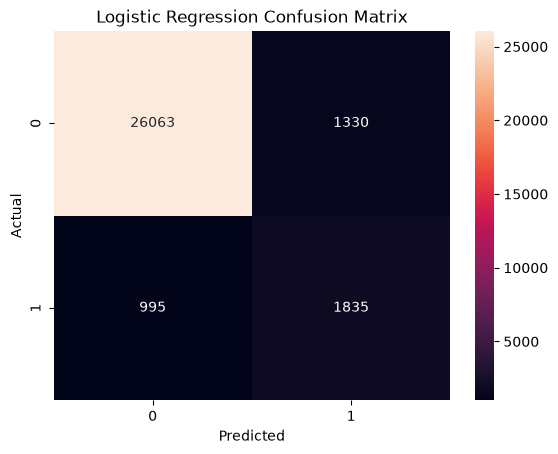

In [21]:
cm = confusion_matrix(
    y_test,
    log_predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [22]:
print(
    classification_report(
        y_test,
        log_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27393
           1       0.58      0.65      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.77      0.80      0.78     30223
weighted avg       0.93      0.92      0.92     30223



In [23]:
results = []

results.append({
    "Model":"Logistic Regression",
    "F1 Score":log_f1,
    "AUC-PR":log_auc_pr
})

pd.DataFrame(results)

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.612177,0.659632


## Random Forest Ensemble Model

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [26]:
rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [27]:
rf_predictions = rf_model.predict(
    X_test
)

In [28]:
rf_probabilities = rf_model.predict_proba(
    X_test
)[:,1]

In [29]:
rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_f1

0.6079239302694136

In [30]:
rf_auc_pr = average_precision_score(
    y_test,
    rf_probabilities
)

rf_auc_pr

0.7037349251462944

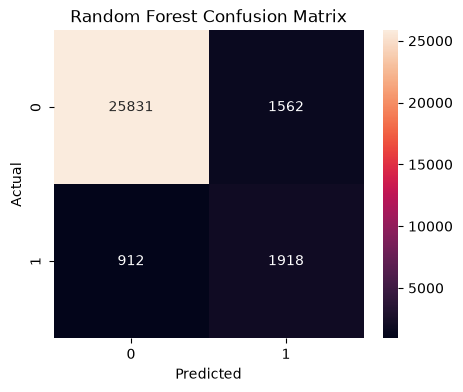

In [31]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [32]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     27393
           1       0.55      0.68      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.76      0.81      0.78     30223
weighted avg       0.93      0.92      0.92     30223



In [33]:
model_results = pd.DataFrame(
    [
        {
            "Model":"Logistic Regression",
            "F1 Score":log_f1,
            "AUC-PR":log_auc_pr
        },
        {
            "Model":"Random Forest",
            "F1 Score":rf_f1,
            "AUC-PR":rf_auc_pr
        }
    ]
)

In [34]:
model_results

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.612177,0.659632
1,Random Forest,0.607924,0.703735


<Figure size 800x400 with 0 Axes>

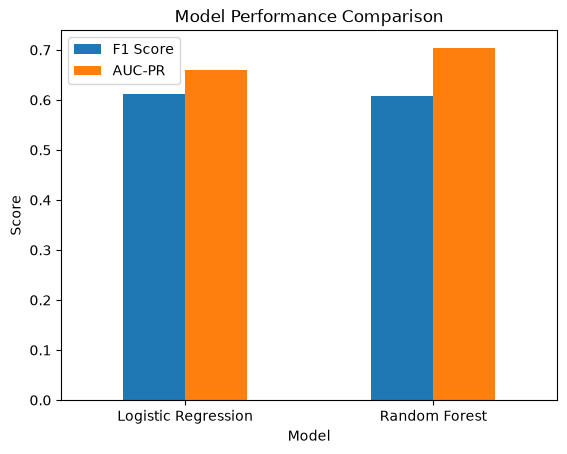

In [35]:
plt.figure(figsize=(8,4))

model_results.set_index(
    "Model"
)[
    [
        "F1 Score",
        "AUC-PR"
    ]
].plot(
    kind="bar"
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=0
)

plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15]
}

In [38]:
grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

In [39]:
grid_search.fit(
    X_train_resampled,
    y_train_resampled
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information print

In [40]:
grid_search.best_params_

{'max_depth': 15, 'n_estimators': 100}

In [41]:
grid_search.best_score_

np.float64(0.8972972857004305)

In [42]:
best_rf_model = grid_search.best_estimator_

In [43]:
best_rf_predictions = best_rf_model.predict(
    X_test
)

best_rf_probabilities = best_rf_model.predict_proba(
    X_test
)[:,1]

In [44]:
best_rf_f1 = f1_score(
    y_test,
    best_rf_predictions
)

In [45]:
best_rf_auc_pr = average_precision_score(
    y_test,
    best_rf_probabilities
)

In [46]:
print(
    "F1:",
    best_rf_f1
)

print(
    "AUC-PR:",
    best_rf_auc_pr
)

F1: 0.6416713299757508
AUC-PR: 0.7026369329572171


In [47]:
from sklearn.model_selection import StratifiedKFold

In [48]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [49]:
cv_scores = cross_val_score(
    best_rf_model,
    X_train_resampled,
    y_train_resampled,
    cv=cv,
    scoring="f1"
)

In [50]:
cv_scores

array([0.90181765, 0.90399825, 0.90311184, 0.89809783, 0.90416385])

In [51]:
cv_scores.mean()

np.float64(0.9022378839486308)

In [52]:
cv_scores.std()

np.float64(0.002231084826289543)

In [53]:
joblib.dump(
    best_rf_model,
    "../models/best_fraud_random_forest.pkl"
)

['../models/best_fraud_random_forest.pkl']

In [54]:
final_results = pd.DataFrame(
    [
        {
            "Model":"Logistic Regression",
            "F1 Score":log_f1,
            "AUC-PR":log_auc_pr
        },
        {
            "Model":"Random Forest Tuned",
            "F1 Score":best_rf_f1,
            "AUC-PR":best_rf_auc_pr
        }
    ]
)

In [55]:
final_results.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

In [56]:
final_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "F1 Score": log_f1,
            "AUC-PR": log_auc_pr
        },
        {
            "Model": "Random Forest Tuned",
            "F1 Score": best_rf_f1,
            "AUC-PR": best_rf_auc_pr
        }
    ]
)

final_comparison

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.612177,0.659632
1,Random Forest Tuned,0.641671,0.702637


In [57]:
final_comparison.to_csv(
    "../data/processed/final_model_comparison.csv",
    index=False
)

In [58]:
final_comparison.sort_values(
    by="AUC-PR",
    ascending=False
)

,Model,F1 Score,AUC-PR
1,Random Forest Tuned,0.641671,0.702637
0,Logistic Regression,0.612177,0.659632


In [59]:
selected_model = "Random Forest Tuned"

# Final Model Evaluation

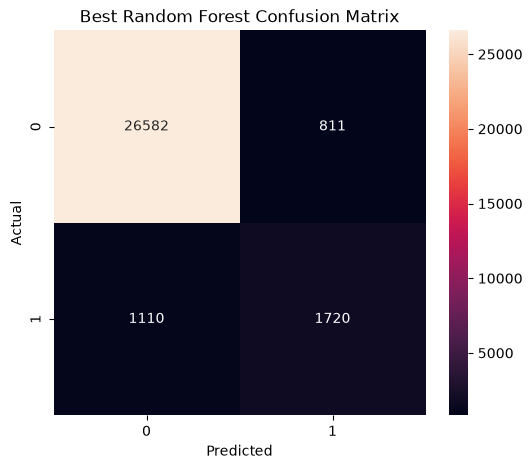

In [60]:
cm = confusion_matrix(
    y_test,
    best_rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best Random Forest Confusion Matrix")

plt.show()

In [61]:
from sklearn.metrics import precision_recall_curve

In [62]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    best_rf_probabilities
)

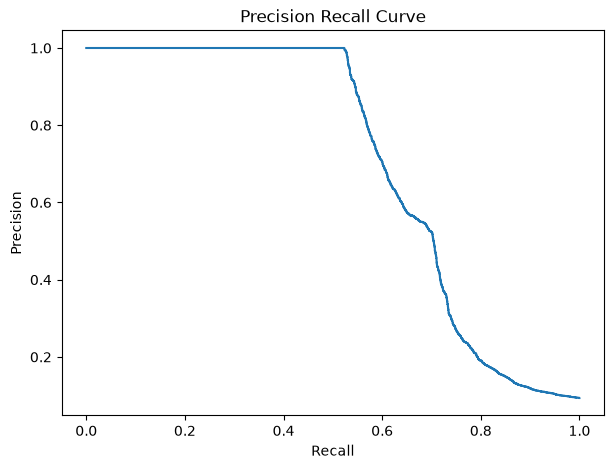

In [63]:
plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision Recall Curve"
)

plt.show()

In [64]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": best_rf_model.feature_importances_
    }
)

In [65]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [66]:
feature_importance.head(10)

,Feature,Importance
8,device_transaction_count,0.400517
6,time_since_signup_hours,0.229398
4,purchase_month,0.165530
186,country_United States,0.020437
15,sex_M,0.018689
10,source_SEO,0.017898
12,browser_IE,0.017577
9,source_Direct,0.012487
14,browser_Safari,0.011566
11,browser_FireFox,0.010918


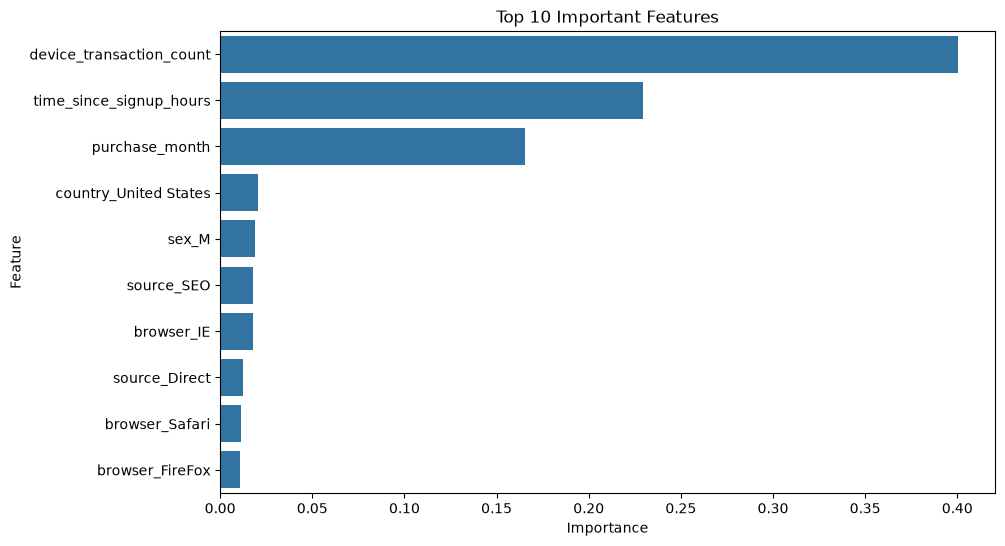

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [68]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)